#### Import required packages

In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import RFECV

#### Import sample data and drop uneccessary columns

In [18]:
data_for_model = pd.read_pickle("data/abc_classification_modelling.p")
data_for_model.drop("customer_id", axis = 1, inplace = True)
print(data_for_model.columns)

Index(['signup_flag', 'distance_from_store', 'gender', 'credit_score',
       'total_sales', 'total_items', 'transaction_count', 'product_area_count',
       'average_basket_value'],
      dtype='object')


#### Shuffle data

In [19]:
data_for_model = shuffle(data_for_model, random_state = 42)
print(data_for_model)

     signup_flag  distance_from_store gender  credit_score  total_sales  \
714            0                 1.64      M          0.58        27.81   
605            0                 0.88      M          0.63        26.62   
120            0                 0.56      M          0.62       886.78   
208            0                 0.11      M          0.58      1256.19   
380            0                 1.32      M          0.36       739.67   
..           ...                  ...    ...           ...          ...   
71             0                 0.07      M          0.57       746.15   
106            0                 1.96      F          0.60       881.49   
270            0                 1.59      M          0.50       319.37   
435            0                 0.71      F          0.54       273.94   
102            0                 2.60      F          0.48       523.41   

     total_items  transaction_count  product_area_count  average_basket_value  
714            6   

#### Class Balance

In [20]:
data_for_model["signup_flag"].value_counts(normalize = True)

signup_flag
0    0.689535
1    0.310465
Name: proportion, dtype: float64

#### Dealing with missing values

In [21]:
data_for_model.isna().sum()
data_for_model.dropna(how = "any", inplace = True)

#### Dealing with outliers

In [22]:
outlier_investigation = data_for_model.describe()

outlier_columns = ["distance_from_store", "total_sales", "total_items"]

# Boxplot approach

for column in outlier_columns:

    lower_quartile = data_for_model[column].quantile(0.25)
    upper_quartile = data_for_model[column].quantile(0.75)
    iqr = upper_quartile - lower_quartile
    iqr_extended = iqr * 2
    min_border = lower_quartile - iqr_extended
    max_border = upper_quartile + iqr_extended

    outliers = data_for_model[(data_for_model[column] < min_border) | (data_for_model[column] > max_border)]
    print(f"{len(outliers)} outliers detected in column {column}")

    data_for_model.drop(outliers.index, inplace = True)

8 outliers detected in column distance_from_store
54 outliers detected in column total_sales
3 outliers detected in column total_items


#### Split Input variables and Output variables

In [23]:
X = data_for_model.drop(["signup_flag"], axis = 1)
y = data_for_model["signup_flag"]

#### Split out training and test sets

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

#### Dealing with categorical variables

In [25]:
categorical_vars = ["gender"]

one_hot_encoder = OneHotEncoder(sparse_output = False, drop = "first")

X_train_encoded = one_hot_encoder.fit_transform(X_train[categorical_vars])
X_test_encoded = one_hot_encoder.transform(X_test[categorical_vars])

encoder_feature_names = one_hot_encoder.get_feature_names_out(categorical_vars)

X_train_encoded = pd.DataFrame(X_train_encoded, columns = encoder_feature_names)
X_train = pd.concat([X_train.reset_index(drop = True), X_train_encoded.reset_index(drop = True)], axis = 1)
X_train.drop(categorical_vars, axis = 1, inplace = True)

X_test_encoded = pd.DataFrame(X_test_encoded, columns = encoder_feature_names)
X_test = pd.concat([X_test.reset_index(drop = True), X_test_encoded.reset_index(drop = True)], axis = 1)
X_test.drop(categorical_vars, axis = 1, inplace = True)

In [26]:
print(X_train)

     distance_from_store  credit_score  total_sales  total_items  \
0                   0.07          0.57       746.15          133   
1                   0.20          0.57       585.46          128   
2                   3.07          0.53      1151.24          226   
3                   2.86          0.77        14.03            8   
4                   0.52          0.52       656.48          121   
..                   ...           ...          ...          ...   
620                 0.39          0.72       564.47          146   
621                 1.62          0.72       793.91          171   
622                 2.60          0.65       847.01          123   
623                 0.36          0.45       924.07          189   
624                 1.36          0.59       429.66           95   

     transaction_count  product_area_count  average_basket_value  gender_M  
0                   24                   5             31.089583       1.0  
1                   32       

#### Feature Selection

In [27]:
clf = LogisticRegression(random_state = 42, max_iter = 1000)
feature_selector = RFECV(clf)

fit = feature_selector.fit(X_train, y_train)

optimal_feature_count = feature_selector.n_features_
print(f"Optimal number of features : {optimal_feature_count}")

Optimal number of features : 7


In [28]:
X_train = X_train.loc[:, feature_selector.get_support()]
X_test = X_test.loc[:, feature_selector.get_support()]
print(X_train)

     distance_from_store  credit_score  total_items  transaction_count  \
0                   0.07          0.57          133                 24   
1                   0.20          0.57          128                 32   
2                   3.07          0.53          226                 35   
3                   2.86          0.77            8                  2   
4                   0.52          0.52          121                 16   
..                   ...           ...          ...                ...   
620                 0.39          0.72          146                 25   
621                 1.62          0.72          171                 20   
622                 2.60          0.65          123                 22   
623                 0.36          0.45          189                 20   
624                 1.36          0.59           95                 26   

     product_area_count  average_basket_value  gender_M  
0                     5             31.089583       1

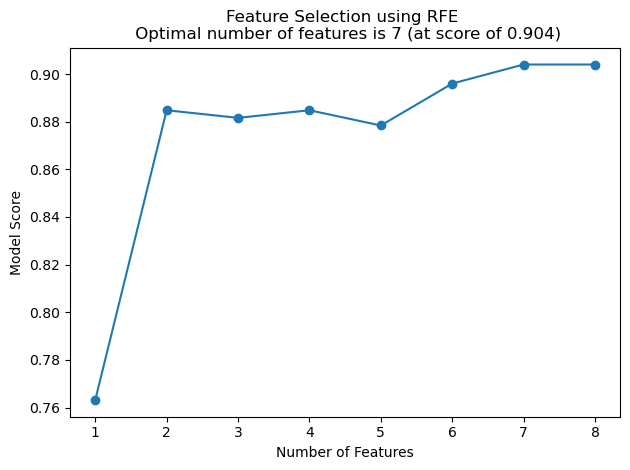

In [29]:
plt.plot(range(1, len(fit.cv_results_['mean_test_score']) + 1), fit.cv_results_['mean_test_score'], marker = "o")
plt.ylabel("Model Score")
plt.xlabel("Number of Features")
plt.title(f"Feature Selection using RFE \n Optimal number of features is {optimal_feature_count} (at score of {round(max(fit.cv_results_['mean_test_score']),4)})")
plt.tight_layout()
plt.show()

#### Model Training

In [30]:
clf = LogisticRegression(random_state = 42, max_iter = 1000)
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Model Assessment

In [31]:
y_pred_class = clf.predict(X_test)
print(y_pred_class)

[0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 1
 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0
 0 1 1 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 1 1 0 1 0 1 0 0 0 0
 0 0 0 1 0 0 0 1 0]


In [33]:
y_pred_prob = clf.predict_proba(X_test)[:,1]
print(y_pred_prob)

[9.97462548e-03 1.66928452e-01 7.78999225e-01 5.12786760e-02
 4.88963235e-03 9.31747444e-01 2.86380369e-05 4.76799841e-02
 9.30092614e-06 1.63713933e-04 4.04119456e-02 1.36546160e-02
 2.90189695e-03 5.67263806e-02 1.25313980e-02 4.32307229e-01
 1.05490455e-02 3.77142990e-04 7.13773139e-03 6.14405068e-02
 6.12747535e-01 7.46954927e-01 7.46826562e-01 5.88968188e-01
 8.59742693e-04 2.35942225e-03 6.04649875e-03 3.07491664e-01
 1.52686075e-01 1.33750696e-01 8.33532766e-01 9.99452318e-01
 2.38035442e-01 1.63718584e-02 9.49699602e-02 4.79263301e-05
 9.84201180e-01 1.36893855e-01 1.54351422e-04 6.26097323e-01
 6.60496400e-04 9.05123600e-03 1.80444555e-02 3.77448579e-01
 1.91879798e-02 2.21035904e-02 8.56239335e-01 2.09032837e-02
 3.56373411e-02 1.16191594e-02 1.28721265e-01 2.07957732e-01
 6.38935592e-01 1.33812140e-01 2.16833490e-01 1.35780973e-02
 8.82178970e-01 6.52732148e-01 9.89542245e-02 3.21083037e-01
 7.75955500e-01 5.27420433e-01 6.05484186e-03 1.29953868e-02
 4.68509082e-01 1.082313

#### Confusion matrix

In [35]:
conf_matrix = confusion_matrix(y_test, y_pred_class)
print(conf_matrix)

[[107   8]
 [ 13  29]]


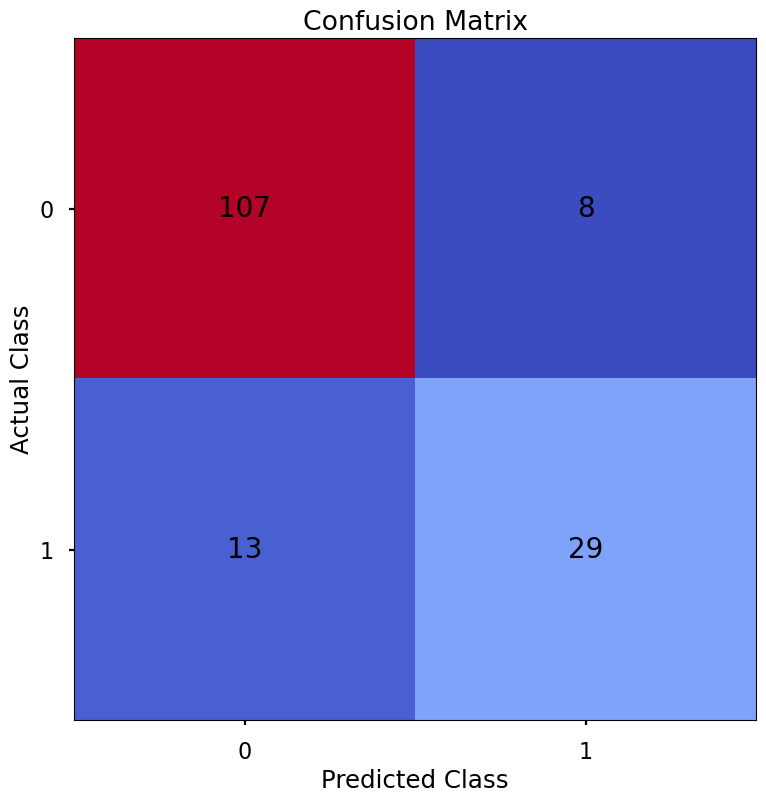

In [36]:
plt.style.use("seaborn-v0_8-poster")
plt.matshow(conf_matrix, cmap = "coolwarm")
plt.gca().xaxis.tick_bottom()
plt.title("Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
for (i, j), corr_value in np.ndenumerate(conf_matrix):
    plt.text(j, i, corr_value, ha = "center", va = "center", fontsize = 20)
plt.show()

 #### Accuracy (the number of correct classification out of all attempted classifications)

In [37]:
accuracy_score(y_test, y_pred_class)

0.8662420382165605

#### Precision (of all observations that were predicted as positive, how many were actually positive)

In [38]:
precision_score(y_test, y_pred_class)

0.7837837837837838

#### Recall (of all positive observations, how many did we predict as positive)

In [39]:
recall_score(y_test, y_pred_class)

0.6904761904761905

#### F1-Score (the harmonic mean of precision and recall)

In [40]:
f1_score(y_test, y_pred_class)

0.7341772151898734

#### Finding the optimal threshold

In [43]:
thresholds = np.arange(0, 1, 0.01)
print(thresholds)

[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]


In [47]:
precision_scores = []
recall_scores = []
f1_scores = []

for threshold in thresholds:

    pred_class = (y_pred_prob >= threshold) * 1

    precision = precision_score(y_test, pred_class, zero_division = 0)
    precision_scores.append(precision)

    recall = recall_score(y_test, pred_class)
    recall_scores.append(recall)

    f1 = f1_score(y_test, pred_class)
    f1_scores.append(f1)

print(f1_scores)

[0.4221105527638191, 0.5359477124183006, 0.5481481481481482, 0.5581395348837209, 0.5555555555555556, 0.5691056910569106, 0.5833333333333334, 0.5932203389830508, 0.603448275862069, 0.603448275862069, 0.6306306306306306, 0.6363636363636364, 0.6363636363636364, 0.6542056074766355, 0.6796116504854369, 0.6796116504854369, 0.6862745098039216, 0.7070707070707071, 0.7216494845360825, 0.7291666666666666, 0.7368421052631579, 0.7446808510638298, 0.7526881720430108, 0.7526881720430108, 0.7608695652173914, 0.7472527472527473, 0.7472527472527473, 0.7472527472527473, 0.7472527472527473, 0.7472527472527473, 0.7555555555555555, 0.7640449438202247, 0.7640449438202247, 0.75, 0.75, 0.75, 0.75, 0.75, 0.7586206896551724, 0.7674418604651163, 0.7674418604651163, 0.7674418604651163, 0.7674418604651163, 0.7619047619047619, 0.7804878048780488, 0.7804878048780488, 0.7804878048780488, 0.7654320987654321, 0.7654320987654321, 0.7654320987654321, 0.7341772151898734, 0.7341772151898734, 0.7341772151898734, 0.743589743

In [48]:
max_f1 = max(f1_scores)
max_f1_idx = f1_scores.index(max_f1)
print(max_f1)

0.7804878048780488


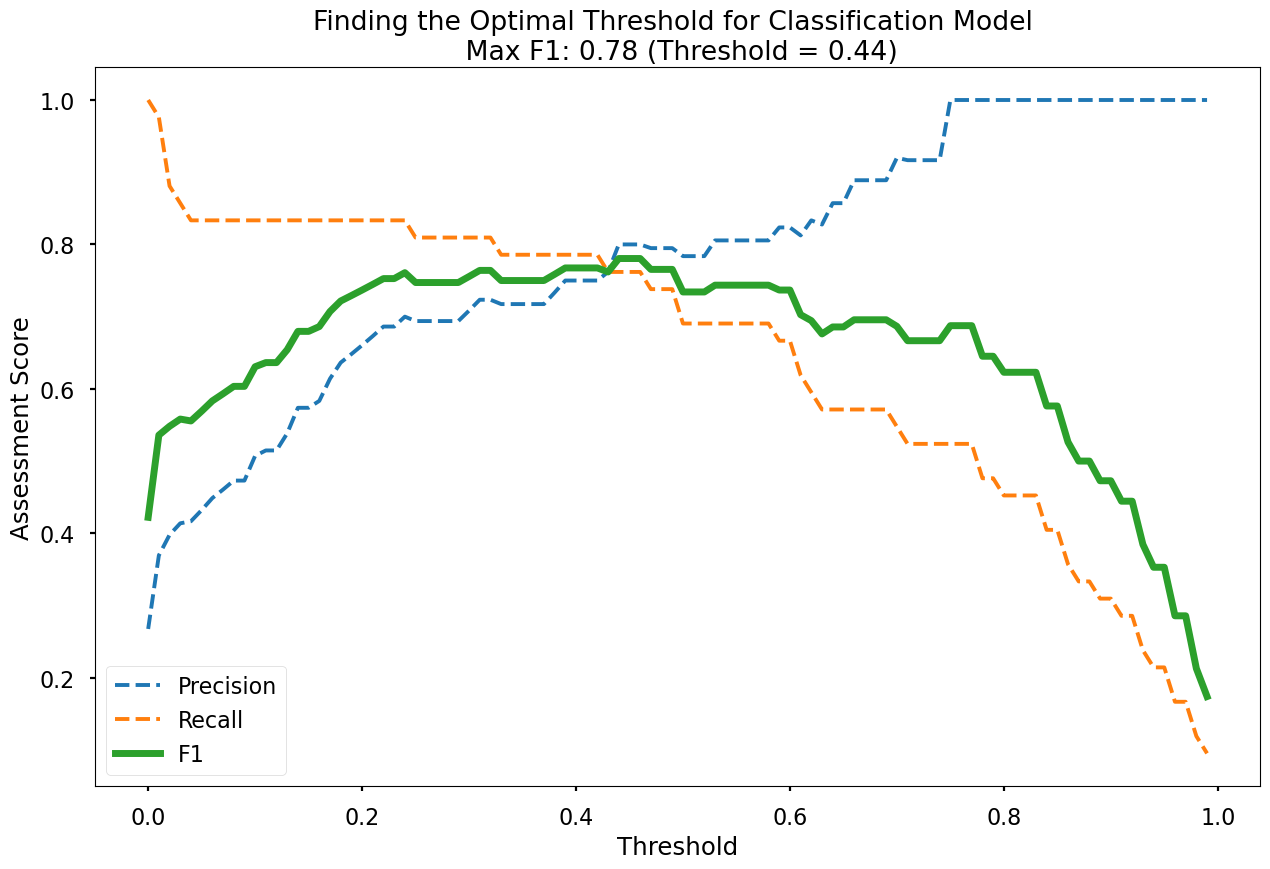

In [50]:
plt.style.use("seaborn-v0_8-poster")
plt.plot(thresholds, precision_scores, label = "Precision", linestyle = "--")
plt.plot(thresholds, recall_scores, label = "Recall", linestyle = "--")
plt.plot(thresholds, f1_scores, label = "F1", linewidth = 5)
plt.title(f"Finding the Optimal Threshold for Classification Model \n Max F1: {round(max_f1,2)} (Threshold = {round(thresholds[max_f1_idx],2)})")
plt.xlabel("Threshold")
plt.ylabel("Assessment Score")
plt.legend(loc = "lower left")
plt.tight_layout()
plt.show()

In [52]:
optimal_threshold = 0.44
y_pred_class_opt_thresh = (y_pred_prob >= optimal_threshold) * 1
print(y_pred_class_opt_thresh)

[0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 1
 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 1 0 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0
 0 1 1 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 1 0 1 0 1 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 1 1 0 1 0 1 0 0 0 0
 0 0 0 1 0 0 0 1 0]
